# Traversal Correction Audit

For every video frame in `summary_df` we compare the **raw** graph location (from DeepLabCut-based assignment: `headstage_graph_node` / `headstage_graph_edge`) against the **corrected** location from `traversal_df` (which fixes tracking noise, smooths glitches, and interpolates gaps).

Each frame falls into exactly one category:

| Category | Meaning |
|---|---|
| `correct` | Raw location matches the corrected traversal location |
| `wrong_node` | Raw has a graph location, but it differs from the corrected one |
| `outside_maze` | Raw has no graph location at all (neither node nor edge assigned) |
| `not_in_traversal` | Frame falls outside any traversal row's frame range (e.g. session start/end gaps) |

Run for all sessions.

In [1]:
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

In [2]:
BASE_DIR = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs')

SESSIONS = sorted(
    d.name for d in BASE_DIR.iterdir()
    if d.is_dir()
    and (d / 'summary_df.csv').exists()
    and (d / 'traversal_df.csv').exists()
)
print(f'Sessions found: {len(SESSIONS)}')
for s in SESSIONS:
    print(' ', s)

Sessions found: 12
  09_09_2025
  10_09_2025
  11_09_2025
  12_08_2025
  13_08_2025
  14_08_2025
  18_08_2025
  19_08_2025
  20_08_2025
  21_08_2025
  24_08_2025
  27_08_2025


## Core Logic

For each session we:
1. Load `summary_df.csv` (skip the DLC header row) and `traversal_df.csv`.
2. Build a frame→corrected-location lookup from the traversal (each row covers `[start_frame_global, end_frame_global]` inclusive).
3. Extract the raw location for each frame (node takes priority over edge).
4. Classify and count.

In [3]:
def parse_edge(val):
    """Convert edge string like "('L31', 'L43')" to a canonical frozenset for comparison."""
    if pd.isna(val):
        return None
    if isinstance(val, (tuple, list)):
        return frozenset(str(x) for x in val)
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, (tuple, list)) and len(parsed) == 2:
                return frozenset(str(x) for x in parsed)
        except (ValueError, SyntaxError):
            pass
    return None


def load_summary(session_dir: Path) -> pd.DataFrame:
    """Load summary_df.csv, skip the DLC sub-header row, cast numeric columns."""
    df = pd.read_csv(session_dir / 'summary_df.csv', low_memory=False)
    # First row is the DLC x/y/likelihood header — drop it
    df = df.iloc[1:].reset_index(drop=True)
    df['frame_idx_global'] = pd.to_numeric(df['frame_idx_global'], errors='coerce')
    df['trial_idx']        = pd.to_numeric(df['trial_idx'],        errors='coerce')
    return df


def build_frame_lookup(traversal: pd.DataFrame):
    """
    Return a dict: frame_int -> (corrected_location, location_type)
    where corrected_location is a node string or a frozenset of two node strings (edge).
    Covers all frames in [start_frame_global, end_frame_global] for each traversal row.
    """
    lookup = {}
    for _, row in traversal.iterrows():
        loc_type = row['location_type']
        if loc_type == 'node':
            corrected = str(row['headstage_graph_node'])
        else:  # edge
            corrected = parse_edge(row['headstage_graph_edge'])
            if corrected is None:
                continue
        start = int(row['start_frame_global'])
        end   = int(row['end_frame_global'])
        for f in range(start, end + 1):
            lookup[f] = (corrected, loc_type)
    return lookup


def classify_frame(raw_node, raw_edge, corrected_loc, corrected_type):
    """
    Compare the raw DLC-assigned location against the corrected traversal location.

    Returns one of: 'correct', 'wrong_node', 'outside_maze'
    """
    has_raw_node = pd.notna(raw_node) and raw_node != ''
    has_raw_edge = pd.notna(raw_edge) and raw_edge != ''

    if not has_raw_node and not has_raw_edge:
        return 'outside_maze'

    # Normalise raw location to the same representation as corrected
    if has_raw_node:
        raw_loc  = str(raw_node)
        raw_type = 'node'
    else:
        raw_loc  = parse_edge(raw_edge)
        raw_type = 'edge'
        if raw_loc is None:
            return 'outside_maze'

    if raw_type != corrected_type:
        return 'wrong_node'

    if raw_loc == corrected_loc:
        return 'correct'
    return 'wrong_node'


def audit_session(session_name: str) -> pd.DataFrame:
    """
    Returns a per-frame audit DataFrame with columns:
      frame_idx_global, trial_idx,
      raw_node, raw_edge,
      corrected_loc, corrected_type,
      category   ('correct' | 'wrong_node' | 'outside_maze' | 'not_in_traversal')
    """
    d         = BASE_DIR / session_name
    summary   = load_summary(d)
    traversal = pd.read_csv(d / 'traversal_df.csv')
    lookup    = build_frame_lookup(traversal)

    records = []
    for _, row in summary.iterrows():
        fg = row['frame_idx_global']
        if pd.isna(fg):
            continue
        fg_int = int(fg)

        raw_node = row.get('headstage_graph_node')
        raw_edge = row.get('headstage_graph_edge')

        if fg_int not in lookup:
            category = 'not_in_traversal'
            corrected_loc  = None
            corrected_type = None
        else:
            corrected_loc, corrected_type = lookup[fg_int]
            category = classify_frame(raw_node, raw_edge, corrected_loc, corrected_type)

        records.append({
            'frame_idx_global': fg_int,
            'trial_idx':        row.get('trial_idx'),
            'raw_node':         raw_node if pd.notna(raw_node) else None,
            'raw_edge':         raw_edge if pd.notna(raw_edge) else None,
            'corrected_loc':    str(corrected_loc) if corrected_loc is not None else None,
            'corrected_type':   corrected_type,
            'category':         category,
        })

    return pd.DataFrame(records)

In [4]:
audit_results = {}  # session_name -> audit DataFrame

for session in SESSIONS:
    print(f'Auditing {session} ...', end=' ')
    df = audit_session(session)
    audit_results[session] = df
    counts = df['category'].value_counts()
    total  = len(df)
    print(
        f"{total:>7,} frames  "
        f"correct={counts.get('correct', 0):>6,}  "
        f"wrong_node={counts.get('wrong_node', 0):>6,}  "
        f"outside_maze={counts.get('outside_maze', 0):>6,}  "
        f"not_in_traversal={counts.get('not_in_traversal', 0):>5,}"
    )

print('\nDone.')

Auditing 09_09_2025 ... 128,986 frames  correct=124,743  wrong_node= 2,580  outside_maze= 1,562  not_in_traversal=  101
Auditing 10_09_2025 ... 144,686 frames  correct=139,715  wrong_node= 3,054  outside_maze= 1,893  not_in_traversal=   24
Auditing 11_09_2025 ... 148,764 frames  correct=143,358  wrong_node= 3,583  outside_maze= 1,808  not_in_traversal=   15
Auditing 12_08_2025 ... 184,726 frames  correct=155,207  wrong_node= 5,556  outside_maze=15,130  not_in_traversal=8,833
Auditing 13_08_2025 ... 154,555 frames  correct=138,702  wrong_node= 4,157  outside_maze=10,117  not_in_traversal=1,579
Auditing 14_08_2025 ... 204,194 frames  correct=180,284  wrong_node= 4,667  outside_maze=12,248  not_in_traversal=6,995
Auditing 18_08_2025 ... 159,699 frames  correct=140,827  wrong_node= 6,302  outside_maze=10,691  not_in_traversal=1,879
Auditing 19_08_2025 ... 137,466 frames  correct=126,615  wrong_node= 2,423  outside_maze= 6,831  not_in_traversal=1,597
Auditing 20_08_2025 ... 144,471 frames  

## Session-Level Statistics

In [5]:
rows = []
for session, df in audit_results.items():
    total  = len(df)
    counts = df['category'].value_counts()
    n_correct          = counts.get('correct',          0)
    n_wrong_node       = counts.get('wrong_node',       0)
    n_outside_maze     = counts.get('outside_maze',     0)
    n_not_in_traversal = counts.get('not_in_traversal', 0)
    rows.append({
        'session':              session,
        'total_frames':         total,
        'n_correct':            n_correct,
        'n_wrong_node':         n_wrong_node,
        'n_outside_maze':       n_outside_maze,
        'n_not_in_traversal':   n_not_in_traversal,
        'pct_correct':          round(100 * n_correct          / total, 2),
        'pct_wrong_node':       round(100 * n_wrong_node       / total, 2),
        'pct_outside_maze':     round(100 * n_outside_maze     / total, 2),
        'pct_not_in_traversal': round(100 * n_not_in_traversal / total, 2),
    })

stats_df = pd.DataFrame(rows)
print(stats_df[[
    'session', 'total_frames',
    'n_correct', 'n_wrong_node', 'n_outside_maze', 'n_not_in_traversal',
    'pct_correct', 'pct_wrong_node', 'pct_outside_maze',
]].to_string(index=False))

   session  total_frames  n_correct  n_wrong_node  n_outside_maze  n_not_in_traversal  pct_correct  pct_wrong_node  pct_outside_maze
09_09_2025        128986     124743          2580            1562                 101        96.71            2.00              1.21
10_09_2025        144686     139715          3054            1893                  24        96.56            2.11              1.31
11_09_2025        148764     143358          3583            1808                  15        96.37            2.41              1.22
12_08_2025        184726     155207          5556           15130                8833        84.02            3.01              8.19
13_08_2025        154555     138702          4157           10117                1579        89.74            2.69              6.55
14_08_2025        204194     180284          4667           12248                6995        88.29            2.29              6.00
18_08_2025        159699     140827          6302           10691    

## Visualisations

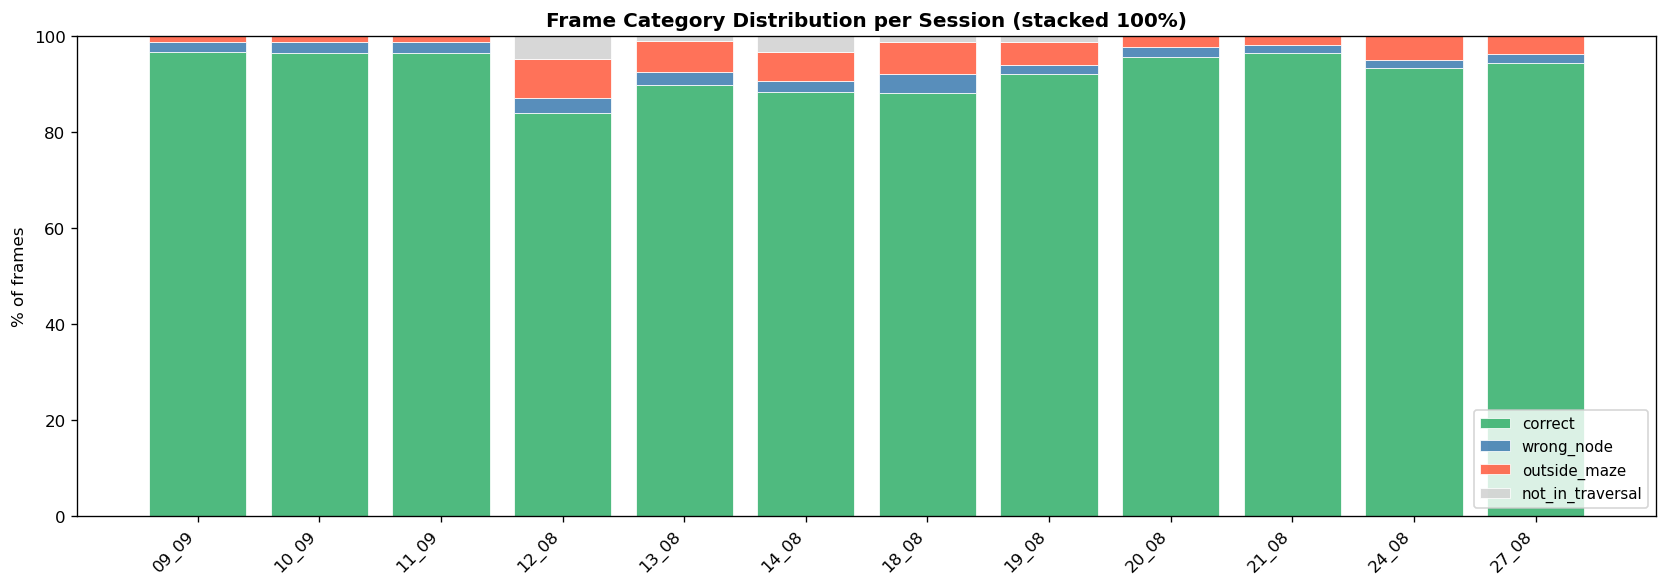

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

x      = range(len(stats_df))
labels = [s.replace('_2025', '') for s in stats_df['session']]

categories = [
    ('pct_correct',          'correct',          'mediumseagreen'),
    ('pct_wrong_node',       'wrong_node',        'steelblue'),
    ('pct_outside_maze',     'outside_maze',      'tomato'),
    ('pct_not_in_traversal', 'not_in_traversal',  'lightgrey'),
]

bottom = np.zeros(len(stats_df))
for col, label, color in categories:
    vals = stats_df[col].values
    ax.bar(x, vals, bottom=bottom, label=label, color=color, alpha=0.9, edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('% of frames')
ax.set_title('Frame Category Distribution per Session (stacked 100%)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

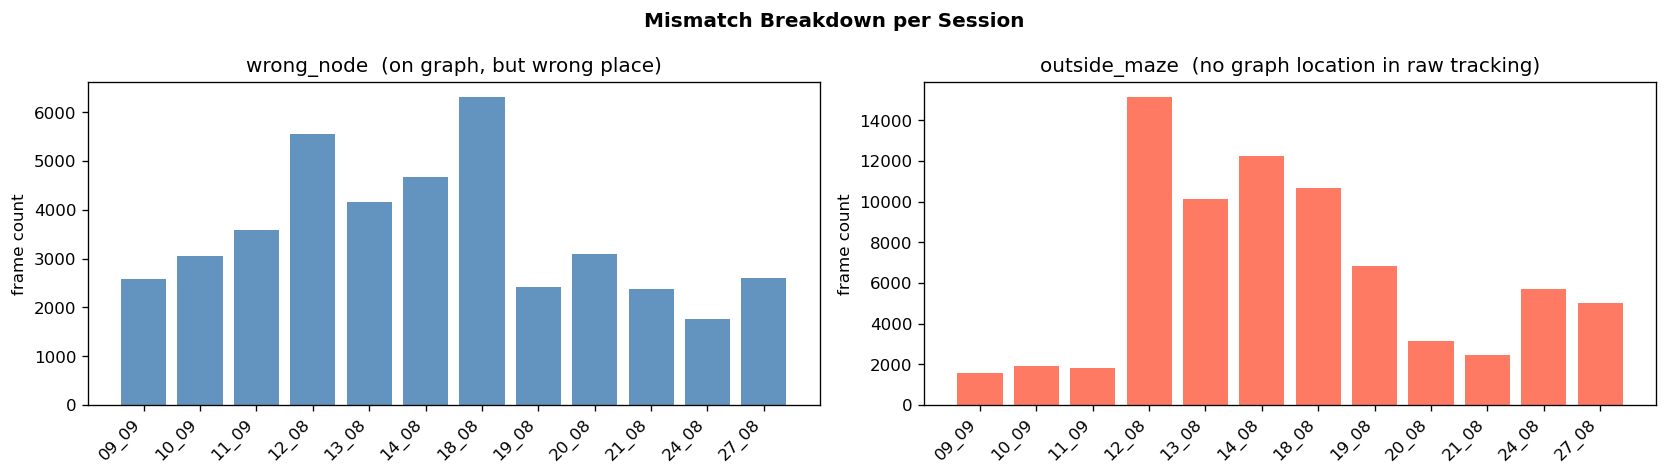

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Mismatch Breakdown per Session', fontweight='bold')

labels = [s.replace('_2025', '') for s in stats_df['session']]
x = range(len(stats_df))

axes[0].bar(x, stats_df['n_wrong_node'],   color='steelblue', alpha=0.85)
axes[0].set_title('wrong_node  (on graph, but wrong place)')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_ylabel('frame count')

axes[1].bar(x, stats_df['n_outside_maze'], color='tomato',    alpha=0.85)
axes[1].set_title('outside_maze  (no graph location in raw tracking)')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_ylabel('frame count')

plt.tight_layout()
plt.show()

## Per-Session Detail

For `wrong_node` frames: what is the most common raw location vs. the corrected location?
For `outside_maze` frames: which corrected locations do they actually belong to (per traversal)?

In [8]:
print('=== wrong_node: top raw-vs-corrected pairs per session ===\n')

for session, df in audit_results.items():
    wrong = df[df['category'] == 'wrong_node'].copy()
    if wrong.empty:
        print(f'{session}: no wrong_node frames')
        continue
    # Combine raw_node / raw_edge into one column for display
    wrong['raw_loc'] = wrong['raw_node'].fillna(wrong['raw_edge'])
    pairs = wrong.groupby(['raw_loc', 'corrected_loc']).size().sort_values(ascending=False).head(10)
    print(f'--- {session}  ({len(wrong):,} wrong_node frames) ---')
    print(pairs.rename('count').to_string())
    print()

=== wrong_node: top raw-vs-corrected pairs per session ===

--- 09_09_2025  (2,580 wrong_node frames) ---
raw_loc          corrected_loc             
('L23', 'L36')   frozenset({'L412', 'L36'})    109
('R36', 'R413')  frozenset({'R23', 'R36'})     106
('R20', 'R31')   frozenset({'R31', 'R42'})      79
R54              frozenset({'R31', 'R42'})      79
R523             frozenset({'R411', 'R35'})     75
('R36', 'R413')  R36                            72
('R31', 'R42')   frozenset({'R31', 'R20'})      65
('R22', 'R35')   frozenset({'R411', 'R35'})     63
R58              frozenset({'R32', 'R44'})      56
('R32', 'R44')   frozenset({'R32', 'R21'})      54

--- 10_09_2025  (3,054 wrong_node frames) ---
raw_loc          corrected_loc             
('R32', 'R44')   frozenset({'R32', 'R21'})     138
('L20', 'L31')   frozenset({'L43', 'L31'})     104
('R22', 'R35')   frozenset({'R411', 'R35'})     88
('R36', 'R413')  frozenset({'R23', 'R36'})      86
('R21', 'R32')   frozenset({'R32', 'R44'})   

In [9]:
print('=== outside_maze: which corrected locations do these frames belong to? ===\n')

for session, df in audit_results.items():
    outside = df[df['category'] == 'outside_maze']
    if outside.empty:
        print(f'{session}: no outside_maze frames')
        continue
    by_corrected = outside['corrected_loc'].value_counts().head(10)
    print(f'--- {session}  ({len(outside):,} outside_maze frames) ---')
    print(by_corrected.to_string())
    print()

=== outside_maze: which corrected locations do these frames belong to? ===

--- 09_09_2025  (1,562 outside_maze frames) ---
corrected_loc
frozenset({'R411', 'R35'})    166
frozenset({'R35', 'R22'})     120
frozenset({'R0', 'R10'})      105
frozenset({'R32', 'R44'})      92
frozenset({'R11', 'R22'})      82
frozenset({'R23', 'R11'})      68
frozenset({'R31', 'R42'})      59
L521                           57
R0                             55
frozenset({'R23', 'R36'})      43

--- 10_09_2025  (1,893 outside_maze frames) ---
corrected_loc
frozenset({'R11', 'R22'})     204
frozenset({'R32', 'R44'})     158
frozenset({'R35', 'R22'})     140
frozenset({'R411', 'R35'})    123
L42                           118
frozenset({'R23', 'R11'})      99
L520                           80
R523                           77
L55                            61
frozenset({'R32', 'R21'})      57

--- 11_09_2025  (1,808 outside_maze frames) ---
corrected_loc
L510                          262
frozenset({'R32', 'R44

## Build Fixed summary_df

Add a `corrected_loc` column and a `corrected_type` column to each session's summary_df based on the traversal, and save as `summary_df_corrected.csv`.

In [10]:
for session in SESSIONS:
    d         = BASE_DIR / session
    summary   = load_summary(d)
    audit     = audit_results[session].set_index('frame_idx_global')

    summary['frame_idx_global_int'] = summary['frame_idx_global'].astype('Int64')

    summary['corrected_loc']  = summary['frame_idx_global_int'].map(
        audit['corrected_loc'].to_dict()
    )
    summary['corrected_type'] = summary['frame_idx_global_int'].map(
        audit['corrected_type'].to_dict()
    )
    summary['frame_category'] = summary['frame_idx_global_int'].map(
        audit['category'].to_dict()
    )
    summary.drop(columns='frame_idx_global_int', inplace=True)

    out_path = d / 'summary_df_corrected.csv'
    summary.to_csv(out_path, index=False)
    print(f'Saved {out_path.name}  ({len(summary):,} rows)')

print('\nAll sessions saved.')

Saved summary_df_corrected.csv  (128,986 rows)
Saved summary_df_corrected.csv  (144,686 rows)
Saved summary_df_corrected.csv  (148,764 rows)
Saved summary_df_corrected.csv  (184,726 rows)
Saved summary_df_corrected.csv  (154,555 rows)
Saved summary_df_corrected.csv  (204,194 rows)
Saved summary_df_corrected.csv  (159,699 rows)
Saved summary_df_corrected.csv  (137,466 rows)
Saved summary_df_corrected.csv  (144,471 rows)
Saved summary_df_corrected.csv  (138,671 rows)
Saved summary_df_corrected.csv  (114,489 rows)
Saved summary_df_corrected.csv  (136,968 rows)

All sessions saved.


## Combined Cross-Session Summary

In [11]:
print('=== Cross-session totals ===')
totals = stats_df[[
    'n_correct', 'n_wrong_node', 'n_outside_maze', 'n_not_in_traversal', 'total_frames'
]].sum()
for k, v in totals.items():
    pct = 100 * v / totals['total_frames'] if k != 'total_frames' else None
    suffix = f'  ({pct:.1f}%)' if pct is not None else ''
    print(f'  {k:<25s} {v:>9,}{suffix}')

print()
print('=== Detailed per-session table ===')
display_cols = [
    'session', 'total_frames',
    'n_wrong_node', 'pct_wrong_node',
    'n_outside_maze', 'pct_outside_maze',
    'pct_correct',
]
print(stats_df[display_cols].to_string(index=False))

=== Cross-session totals ===
  n_correct                 1,657,545  (92.2%)
  n_wrong_node                 42,133  (2.3%)
  n_outside_maze               76,615  (4.3%)
  n_not_in_traversal           21,382  (1.2%)
  total_frames              1,797,675

=== Detailed per-session table ===
   session  total_frames  n_wrong_node  pct_wrong_node  n_outside_maze  pct_outside_maze  pct_correct
09_09_2025        128986          2580            2.00            1562              1.21        96.71
10_09_2025        144686          3054            2.11            1893              1.31        96.56
11_09_2025        148764          3583            2.41            1808              1.22        96.37
12_08_2025        184726          5556            3.01           15130              8.19        84.02
13_08_2025        154555          4157            2.69           10117              6.55        89.74
14_08_2025        204194          4667            2.29           12248              6.00        88.2